# **Non-Invasive CKD Screening and Staging Using Cascaded Ensemble Learning with SHAP-Based Explainability**


**Author:** [MonyetttRindam](https://github.com/MonyetttRindam)

**Original Dataset:** [Kaggle](https://www.kaggle.com/datasets/amanik000/kidney-disease-dataset/data?select=kidney_disease_dataset.csv)

**Cleaned Dataset:** [GitHub](https://github.com/fxrdhan/student-exam-performance-dataset-analysis-cleaning/blob/main/StudentPerformanceFactors_clean.csv)

# **Introduction**

Chronic Kidney Disease (CKD) is a serious global health problem characterized by the gradual loss of kidney function over time. Early detection of CKD is crucial in preventing its progression to kidney failure, which often requires dialysis or kidney transplantation. However, traditional diagnostic methods rely heavily on clinical expertise and laboratory tests, which can be time-consuming and may not always detect the disease at an early stage.

In recent years, machine learning techniques have been increasingly applied in the healthcare domain to assist in disease prediction and early diagnosis. These methods are capable of analyzing complex patterns in medical data and providing data-driven decision support for healthcare professionals. In this study, a Kidney Disease Dataset is utilized to support the development of predictive models for kidney disease classification.

The dataset used in this research is a rich collection of clinical and laboratory data derived from patients, designed to support the analysis, diagnosis, and prediction of chronic kidney disease (CKD). It contains 43 diverse features, including demographic information, vital signs, urine and blood test results, medical history, lifestyle factors, and important medical biomarkers such as estimated Glomerular Filtration Rate (eGFR), serum creatinine, and Cystatin C. This dataset is suitable for machine learning modeling, statistical analysis, and correlation studies between health indicators and kidney function.

By leveraging this dataset, this study aims to develop and compare multiple machine learning algorithms for kidney disease prediction, as well as to analyze the most influential clinical features contributing to the prediction results using explainable artificial intelligence techniques.

# **Dataset and Libraries**

## **Import libraries**

In [ ]:
!pip install catboost
!pip install optuna
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.insert(0, '..')

from src.config import RANDOM_STATE, CATBOOST_DEFAULT_PARAMS
from src.data_loader import load_raw, drop_irrelevant_cols, split_data
from src.preprocessing import preprocess_pipeline, fit_scaler, apply_scaler
from src.train_model2 import (build_catboost, tune_catboost, train_model2,
                               save_model2, compute_sample_weights)
from src.evaluate import (stratified_cv_multiclass, eval_multiclass,
                           sensitivity_specificity, plot_confusion_matrix,
                           plot_roc_auc_ovr)
from src.interpret import get_shap_values, plot_shap_bar, plot_shap_beeswarm, plot_shap_force

## **Load Dataset**

In [ ]:
df_raw = load_raw(use_kaggle=True)
df = drop_irrelevant_cols(df_raw, task='multiclass')
print(f'Shape after dropping biomarkers: {df.shape}')
df.sample(5)

[data_loader] Kaggle download failed (No module named 'kagglehub'), falling back to local path.
Shape after dropping biomarkers: (11933, 20)


,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,phosphorus,bicarbonate,calcium,uric_acid,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,ckd_stage
939,10.0,Female,Other Hispanic,NaN,0.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,Unknown
8567,62.0,Female,Non-Hispanic White,5.0,5.00,22.6,59.4,162.0,145.0,94.0,4.0,24.0,9.7,4.0,2.0,NaN,NaN,2.0,NaN,Stage 2 (Mildly Decreased)
2785,13.0,Female,Mexican American,NaN,1.25,23.6,47.4,141.8,106.0,54.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,Unknown
11322,6.0,Female,Non-Hispanic Asian,NaN,NaN,15.4,19.7,113.1,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,Unknown
1511,71.0,Male,Non-Hispanic White,4.0,2.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,1.0,3.0,Unknown


# **Data Understanding**

## **About Dataset**

# Demographics

* **participant_id**: Unique participant identification number (Numerical)
* **age**: Participant age in years (Numerical)
* **gender**: Participant gender category (Categorical)
* **ethnicity**: Participant ethnicity group (Categorical)
* **education_level**: Highest education level attained (Categorical)
* **poverty_income_ratio**: Ratio of household income to poverty threshold (Numerical)

# Body Measurements

* **bmi**: Body Mass Index, indicator of body fat (Numerical)
* **weight_kg**: Body weight in kilograms (Numerical)
* **height_cm**: Body height in centimeters (Numerical)

# Blood Pressure

* **bp_systolic**: Systolic blood pressure measurement in mmHg (Numerical)
* **bp_diastolic**: Diastolic blood pressure measurement in mmHg (Numerical)

# Kidney Function Biomarkers

* **serum_creatinine**: Creatinine concentration in blood, indicator of kidney function (Numerical)
* **blood_urea_nitrogen**: Blood urea nitrogen level, indicator of kidney performance (Numerical)
* **albumin_serum**: Albumin protein concentration in blood serum (Numerical)
* **urine_albumin**: Albumin concentration in urine (Numerical)
* **urine_creatinine**: Creatinine concentration in urine (Numerical)
* **albumin_creatinine_ratio**: Ratio of urine albumin to creatinine (ACR), kidney damage indicator (Numerical)
* **egfr**: Estimated Glomerular Filtration Rate, measurement of kidney filtration efficiency (Numerical)

# Electrolytes & Metabolism

* **phosphorus**: Blood phosphorus concentration (Numerical)
* **bicarbonate**: Blood bicarbonate level related to acid-base balance (Numerical)
* **calcium**: Blood calcium concentration (Numerical)
* **uric_acid**: Uric acid concentration in blood (Numerical)

# Diabetes Indicators

* **diabetes_diagnosed**: Whether the participant has diagnosed diabetes (Categorical)
* **insulin_use**: Whether the participant uses insulin treatment (Categorical)
* **diabetes_pills**: Whether the participant takes diabetes medication pills (Categorical)

# Lifestyle Factors

* **ever_smoked**: Whether the participant has ever smoked in their lifetime (Categorical)
* **current_smoker**: Current smoking status of the participant (Categorical)

# Target Variables

* **ckd_stage**: Chronic Kidney Disease stage based on KDIGO 2024 guidelines (Categorical)
* **ckd_present**: Binary CKD classification label, 0 = No CKD and 1 = CKD (Categorical)

## **Preview Dataset**

In [ ]:
df.sample(5)

,age,gender,ethnicity,education_level,poverty_income_ratio,height_cm,phosphorus,bicarbonate,calcium,uric_acid,diabetes_diagnosed,insulin_use,diabetes_pills,smoking_status,age_group,ckd_stage_grouped,MAP,bmi_category
284,48.0,Male,Non-Hispanic White,5.0,3.60,186.8,3.5,24.0,9.5,6.2,2.0,0.0,0.0,never,adult,2,91.333333,obese
762,31.0,Female,Non-Hispanic Asian,4.0,0.58,149.7,3.7,20.0,9.3,5.0,2.0,0.0,0.0,never,adult,1,84.666667,overweight
1543,72.0,Female,Non-Hispanic White,4.0,2.50,156.2,3.3,24.0,9.3,5.4,1.0,2.0,2.0,unknown,elderly,2,78.666667,overweight
1728,74.0,Male,Non-Hispanic White,5.0,0.63,154.7,3.9,26.0,9.6,4.4,2.0,0.0,0.0,never,elderly,2,117.000000,normal
1244,61.0,Female,Non-Hispanic Black,4.0,1.72,160.3,2.9,22.0,9.4,5.5,2.0,0.0,2.0,never,elderly,2,100.333333,obese


## **Data Leakage Prevention**

In machine learning model development, it is important to prevent **data leakage**, a condition where the model gains access to information that is directly related to the target variable, resulting in unrealistically high performance.

In this dataset, several kidney biomarker features are directly involved in CKD diagnosis and staging calculations based on the KDIGO 2024 guidelines. If these features are retained, the model may indirectly “predict” the target too easily without actually learning meaningful patterns from the patient data.

Therefore, the following features will be removed from the dataset:

### Kidney Function Biomarkers (Removed Features)

* **serum_creatinine**: Creatinine concentration in blood, directly related to kidney function assessment (Numerical)

* **blood_urea_nitrogen**: Blood urea nitrogen level, important indicator of kidney performance (Numerical)

* **albumin_serum**: Albumin protein concentration in blood serum (Numerical)

* **urine_albumin**: Albumin concentration in urine, commonly used in CKD diagnosis (Numerical)

* **urine_creatinine**: Creatinine concentration in urine (Numerical)

* **albumin_creatinine_ratio**: Albumin-to-creatinine ratio (ACR), major indicator of kidney damage (Numerical)

* **egfr**: Estimated Glomerular Filtration Rate, primary measurement used for CKD staging (Numerical)

### Additional Removed Features

* **participant_id**: Unique participant identifier that does not provide predictive information for machine learning models (Numerical)

* **ckd_present**: Binary CKD target label removed because this study focuses on multi-class CKD stage classification using `ckd_stage` as the primary target variable (Categorical)

After removing these features, the model is expected to learn CKD-related patterns from demographic factors, lifestyle variables, body measurements, blood pressure, and general health indicators without directly accessing diagnostic kidney biomarkers or irrelevant identifiers.

This approach helps improve model generalization and reduces the risk of information leakage during training and evaluation.



In [ ]:
# Biomarker columns are dropped by drop_irrelevant_cols(task='multiclass').
# ckd_present is dropped; ckd_stage is kept for grouping into Early/Moderate/Advanced.
# See src/config.py: BIOMARKER_COLS
print('Dropped cols:', sorted(set(df_raw.columns) - set(df.columns)))

Dropped cols: ['albumin_creatinine_ratio', 'albumin_serum', 'blood_urea_nitrogen', 'ckd_present', 'egfr', 'participant_id', 'serum_creatinine', 'urine_albumin', 'urine_creatinine']


## **Dataset Summary**

In [ ]:
def dataset_summary(df):
    summary = []

    for col in df.columns:
        non_null = df[col].notnull().sum()
        dtype = df[col].dtype
        nunique = df[col].nunique()

        # tentukan tipe
        col_type = "Categorical" if dtype == "object" or nunique < 10 else "Numerical"

        # ambil unique values hanya jika categorical
        if col_type == "Categorical":
            unique_vals = df[col].dropna().unique()
            unique_vals_str = list(unique_vals[:10])  # batasi biar tidak kepanjangan
        else:
            unique_vals_str = "-"

        summary.append([
            col,
            non_null,
            dtype,
            nunique,
            col_type,
            unique_vals_str
        ])

    summary_df = pd.DataFrame(summary, columns=[
        "Column",
        "Non-Null Count",
        "Dtype",
        "Unique Values",
        "Type",
        "Sample Unique Values"
    ])

    summary_df.index = range(1, len(summary_df) + 1)
    return summary_df

summary_df = dataset_summary(df)
summary_df

,Column,Non-Null Count,Dtype,Unique Values,Type,Sample Unique Values
1,age,2734,float64,69,Numerical,-
2,gender,2734,int64,2,Categorical,"[1, 0]"
3,education_level,2734,int64,5,Categorical,"[4, 3, 1, 0, 2]"
4,poverty_income_ratio,2734,float64,405,Numerical,-
5,height_cm,2734,float64,465,Numerical,-
6,phosphorus,2734,float64,45,Numerical,-
7,bicarbonate,2734,float64,21,Numerical,-
8,calcium,2734,float64,36,Numerical,-
9,uric_acid,2734,float64,93,Numerical,-
10,diabetes_diagnosed,2630,float64,2,Categorical,"[0.0, 1.0]"


In [ ]:
df['ckd_stage_grouped'].value_counts()

,count
ckd_stage_grouped,
2,1875
0,477
1,382


In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\nKolom: {col}")
    print(f"Jumlah unique: {df[col].nunique()}")
    print(f"Values: {df[col].unique()}")

## **Data Understanding Summary**

The dataset contains **11,933 participant records** with a combination of demographic, lifestyle, body measurement, blood pressure, and medical-related features used for Chronic Kidney Disease (CKD) stage classification.

The primary target variable in this study is **`ckd_stage`**, which represents CKD severity levels based on the **KDIGO 2024 guidelines**. The dataset initially included both binary and multi-class CKD labels; however, only the multi-class target is retained for this study.

The dataset consists of both **numerical** and **categorical** variables:

* **Numerical features** include measurements such as age, BMI, blood pressure, weight, height, phosphorus, calcium, bicarbonate, and uric acid.
* **Categorical features** include gender, ethnicity, education level, diabetes indicators, and smoking status.

Several features contain missing values, particularly clinical laboratory variables and lifestyle-related attributes. Features such as `insulin_use`, `current_smoker`, and some laboratory measurements show relatively high missing rates, indicating that appropriate missing value handling techniques will be necessary during preprocessing.

To prevent **data leakage**, kidney biomarker features directly involved in CKD diagnosis and staging calculations were removed from the dataset. These features include serum creatinine, blood urea nitrogen, urine albumin, albumin-creatinine ratio, and eGFR. Additionally, non-informative identifiers such as `participant_id` and unused target labels such as `ckd_present` were also removed.

After feature removal, the dataset focuses on learning CKD-related patterns from more general patient information, including demographics, lifestyle factors, body measurements, blood pressure, and metabolic indicators. This approach is expected to improve model generalization and produce a more realistic machine learning evaluation.

Overall, the dataset provides a modern and relatively large-scale representation of CKD-related patient data compared to many traditional CKD datasets, making it suitable for multi-class CKD stage classification tasks.


# **Exploratory Data Analysis**

## **Data Quality**

In [ ]:
print("Duplicates:", df.duplicated().sum())

print("\nDescriptive Statistics:")
print(df.describe())


print("\nMissing Values Counts:")
print(df.isnull().sum())

print("\nMissing Values Percentage:")
print(df.isnull().sum() / len(df) * 100)

Duplicates: 0

Descriptive Statistics:
       participant_id           age  education_level  poverty_income_ratio  \
count    11933.000000  1.193300e+04      7794.000000          9.892000e+03   
mean    136344.000000  3.831786e+01         3.804978          2.708174e+00   
std       3444.904716  2.560199e+01         1.153750          1.670119e+00   
min     130378.000000  5.397605e-79         1.000000          5.397605e-79   
25%     133361.000000  1.300000e+01         3.000000          1.180000e+00   
50%     136344.000000  3.700000e+01         4.000000          2.500000e+00   
75%     139327.000000  6.200000e+01         5.000000          4.500000e+00   
max     142310.000000  8.000000e+01         9.000000          5.000000e+00   

               bmi    weight_kg    height_cm  bp_systolic  bp_diastolic  \
count  8471.000000  8754.000000  8499.000000  7517.000000   7517.000000   
mean     27.246665    70.549037   159.664549   119.288546     72.748038   
std       8.137781    30.389021  

#### **Missing Value Analysis**

Several features contain a substantial number of missing values, indicating that some measurements or questionnaires were only collected from a subset of participants.

Features with the highest missing percentages include:

| Feature        | Approximate Missing Percentage |
| -------------- | ------------------------------ |
| insulin_use    | ~90.94%                        |
| diabetes_pills | ~80.88%                        |
| current_smoker | ~72.82%                        |

Additionally, several clinical and body measurement variables contain moderate missing values:

| Feature Group                               | Approximate Missing Percentage |
| ------------------------------------------- | ------------------------------ |
| phosphorus, bicarbonate, calcium, uric_acid | ~47%                           |
| education_level                             | ~34%                           |
| bmi, weight_kg, height_cm                   | ~27%–29%                       |
| bp_systolic, bp_diastolic                   | ~37%                           |
| ever_smoked                                 | ~32%                           |

Meanwhile, the following features contain no missing values:

* `age`
* `gender`
* `ethnicity`
* `ckd_stage`

These complete features provide a stable foundation for further analysis and preprocessing.


## **Data Distribution**

### **Target**

,count
ckd_stage,
Unknown,5607
No CKD,3592
Stage 2 (Mildly Decreased),1875
Stage 1 (Kidney Damage),382
Stage 3a (Mild-Moderate),341
Stage 3b (Moderate-Severe),97
Stage 4 (Severely Decreased),28
Stage 5 (Kidney Failure),11


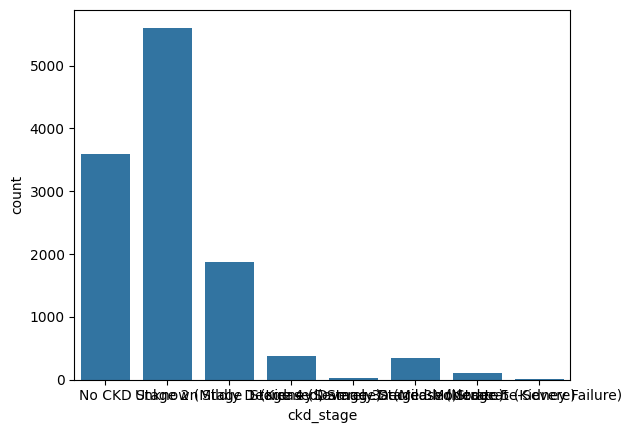

In [ ]:
sns.countplot(x='ckd_stage', data=df)
df['ckd_stage'].value_counts()

#### **Target Variable Distribution (`ckd_stage`)**

The target variable shows a clear class imbalance.

Key observations:

* The **Unknown** category contains the largest number of samples.
* The **No CKD** class is also highly represented.
* Advanced CKD stages such as:

  * Stage 3b
  * Stage 4
  * Stage 5
    contain very few samples.

This imbalance may negatively affect model performance, particularly for severe CKD stage prediction. Therefore, additional preprocessing strategies such as:

* class weighting,
* resampling techniques,
* or imbalance-aware evaluation metrics

may be necessary during model development.


### **Numerical Distribution**

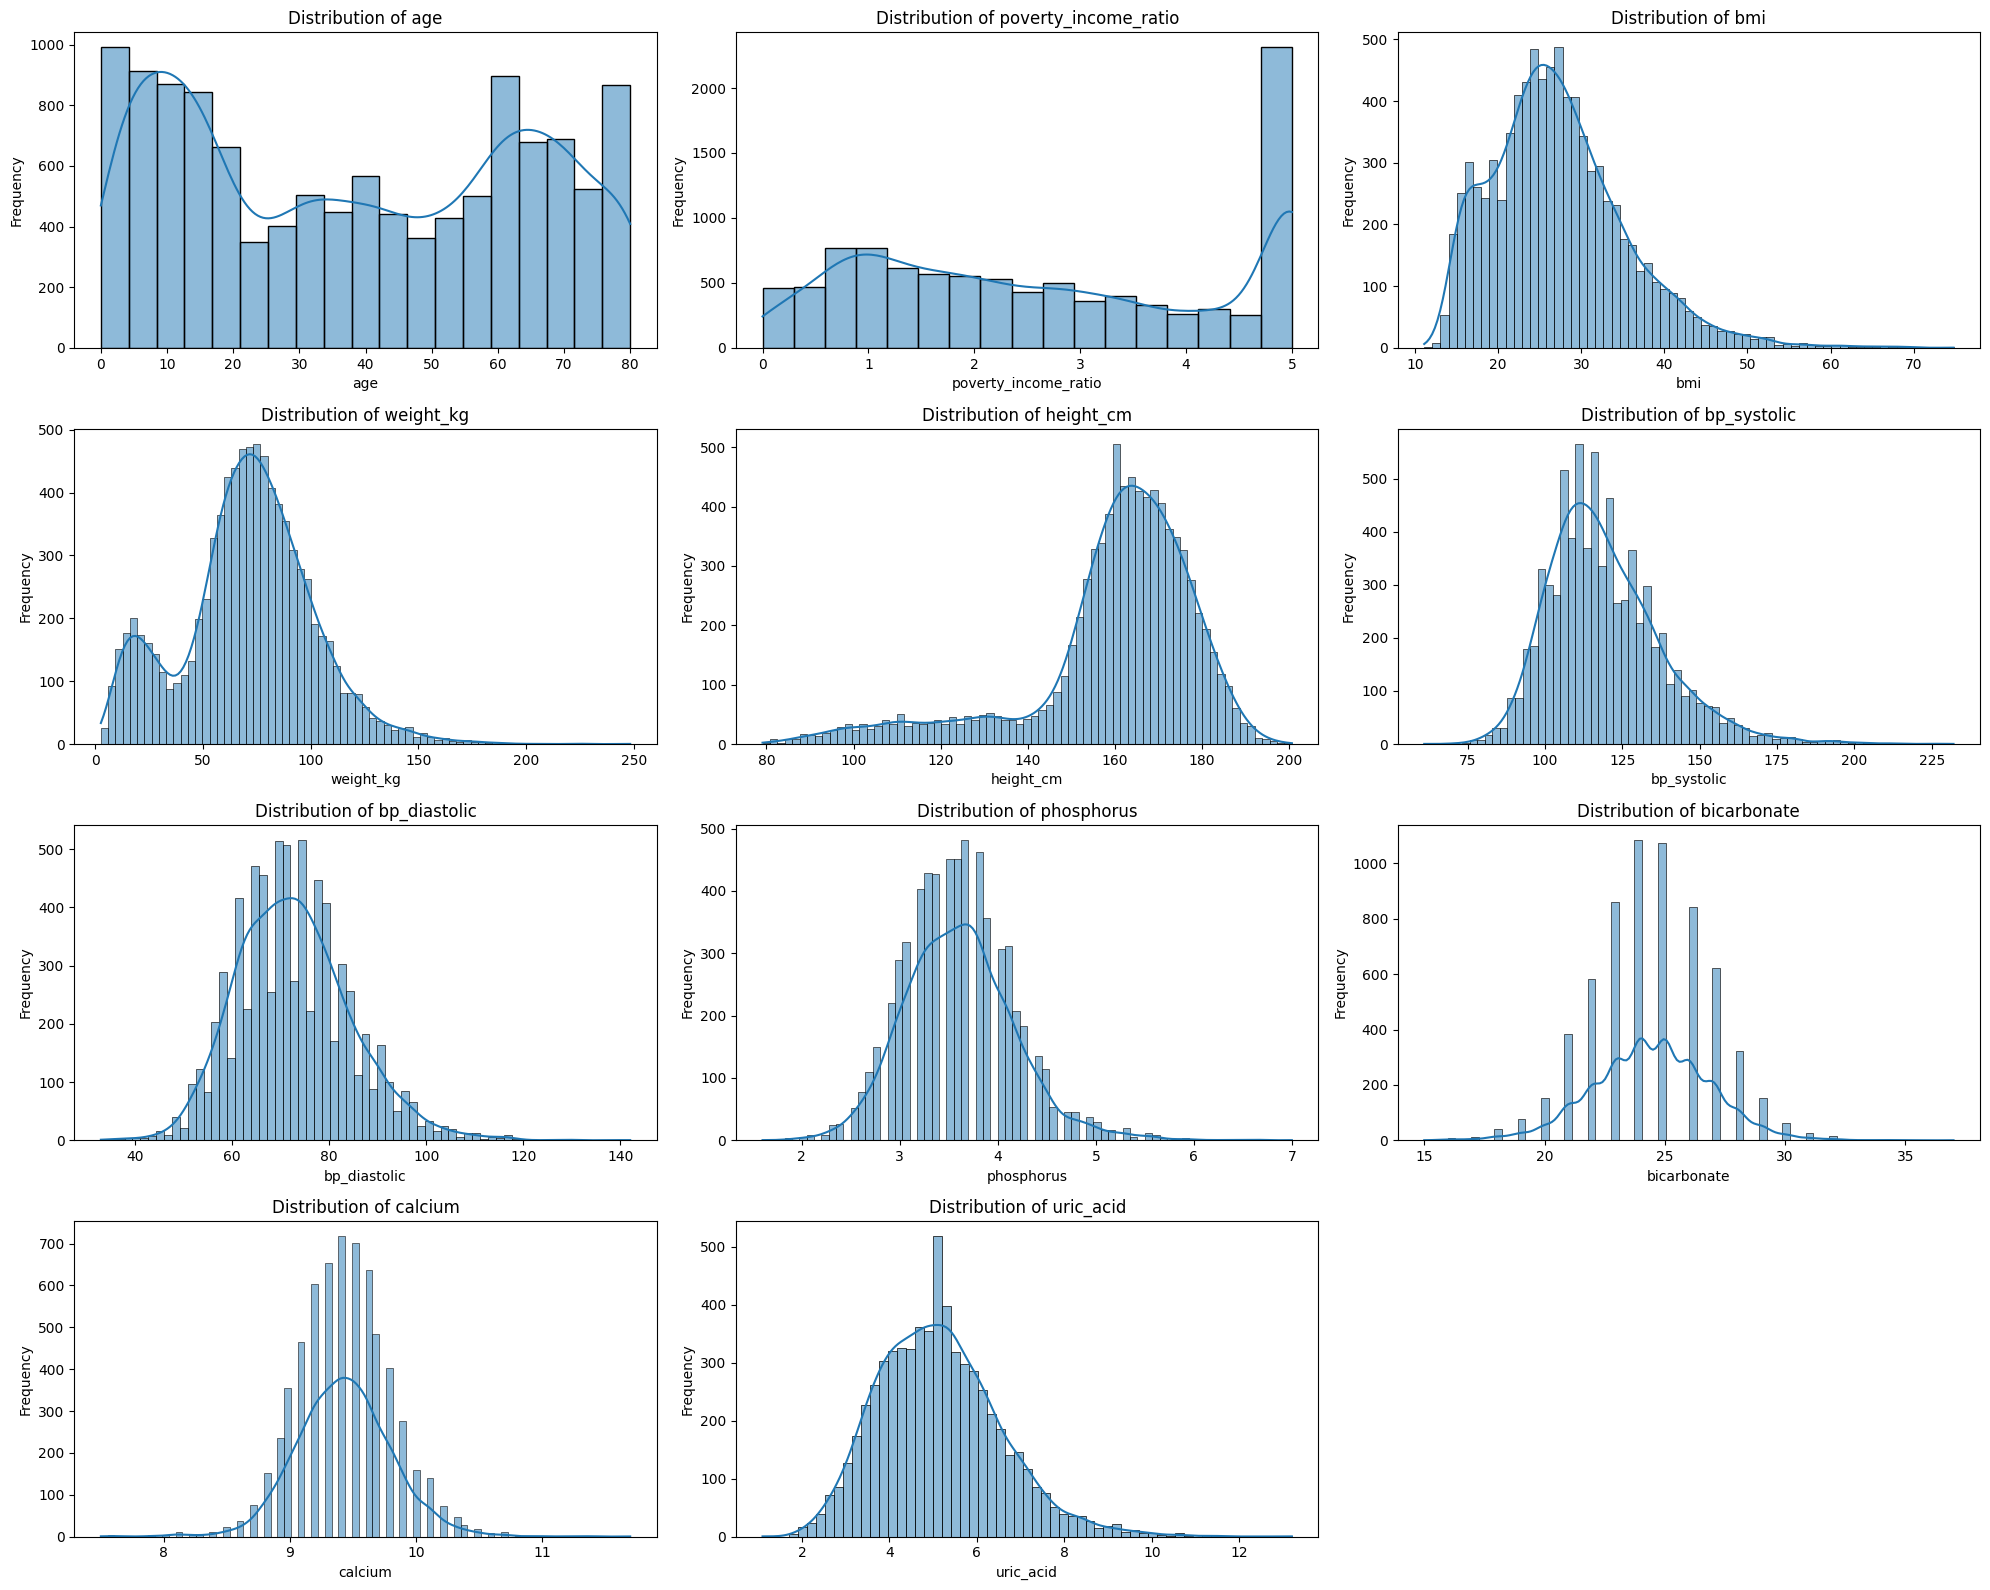

In [ ]:

# Select numerical columns
numerical_cols = [
    'age','poverty_income_ratio','bmi','weight_kg','height_cm','bp_systolic','bp_diastolic','phosphorus','bicarbonate','calcium','uric_acid'
]

# Distribution of Numerical Features
plt.figure(figsize=(20, 16))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)

    sns.histplot(
        df[col].dropna(),
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()



#### **Numerical Analysis**
* **Age**: The age distribution spans a wide range of participants, including children, adults, and elderly individuals. The distribution appears relatively balanced across age groups, with slightly higher frequencies in younger and older age ranges.

* **Poverty Income Ratio**: The distribution is right-skewed, with most participants concentrated in lower-to-middle income categories and fewer participants in higher income groups.

* **BMI**: BMI shows a positively skewed distribution, indicating that many participants fall within overweight and obese categories.

* **Weight (kg)**: Weight distribution is slightly right-skewed with a broad range of values, reflecting variability across different body compositions and age groups.

* **Height (cm)**: Height appears approximately normally distributed, although smaller peaks at lower heights likely represent younger participants.

* **Blood Pressure (Systolic)**: Systolic blood pressure follows a near-normal distribution with slight right skewness, indicating the presence of participants with elevated blood pressure.

* **Blood Pressure (Diastolic)**: Diastolic blood pressure also shows an approximately normal distribution centered around common physiological ranges.

* **Phosphorus**: Phosphorus levels are moderately right-skewed, with most participants clustered around normal physiological values.

* **Bicarbonate**: Bicarbonate values are concentrated within normal ranges and display a relatively symmetric distribution.

* **Calcium**: Calcium levels show a near-normal distribution with low variability, indicating stable calcium measurements among participants.

* **Uric Acid**: Uric acid demonstrates a right-skewed distribution, suggesting the presence of participants with elevated uric acid levels that may indicate metabolic abnormalities or health risks.




#### **Key Insights**

* **Several numerical features are right-skewed**
  Poverty income ratio, BMI, weight, systolic blood pressure, and phosphorus contain long right tails, indicating the presence of participants with unusually high values.

* **Extreme obesity and hypertension patterns are visible**
  BMI, weight, and systolic blood pressure show extreme values that may reflect obesity and hypertension-related health risks within the population.

* **Age shows a bimodal distribution**
  Multiple peaks in the age distribution suggest that the dataset includes both pediatric and elderly participants.

* **Bicarbonate and calcium display discrete multimodal patterns**
  These features contain repeated peaks that may indicate rounded laboratory measurements or data collection artifacts.

* **Some variables are approximately normally distributed**
  Height, diastolic blood pressure, and uric acid appear relatively symmetric and stable, making them suitable for direct statistical analysis.

* **Potential outliers are present in several features**
  Extreme values are observed in BMI, weight, and systolic blood pressure. However, these may represent valid clinical conditions rather than data errors.

* **Different preprocessing strategies may be required**
  Since the dataset contains mixed distribution types, preprocessing techniques such as scaling, transformation, or outlier handling may need to be applied selectively depending on the modeling approach.



### **Categorical Distribution**

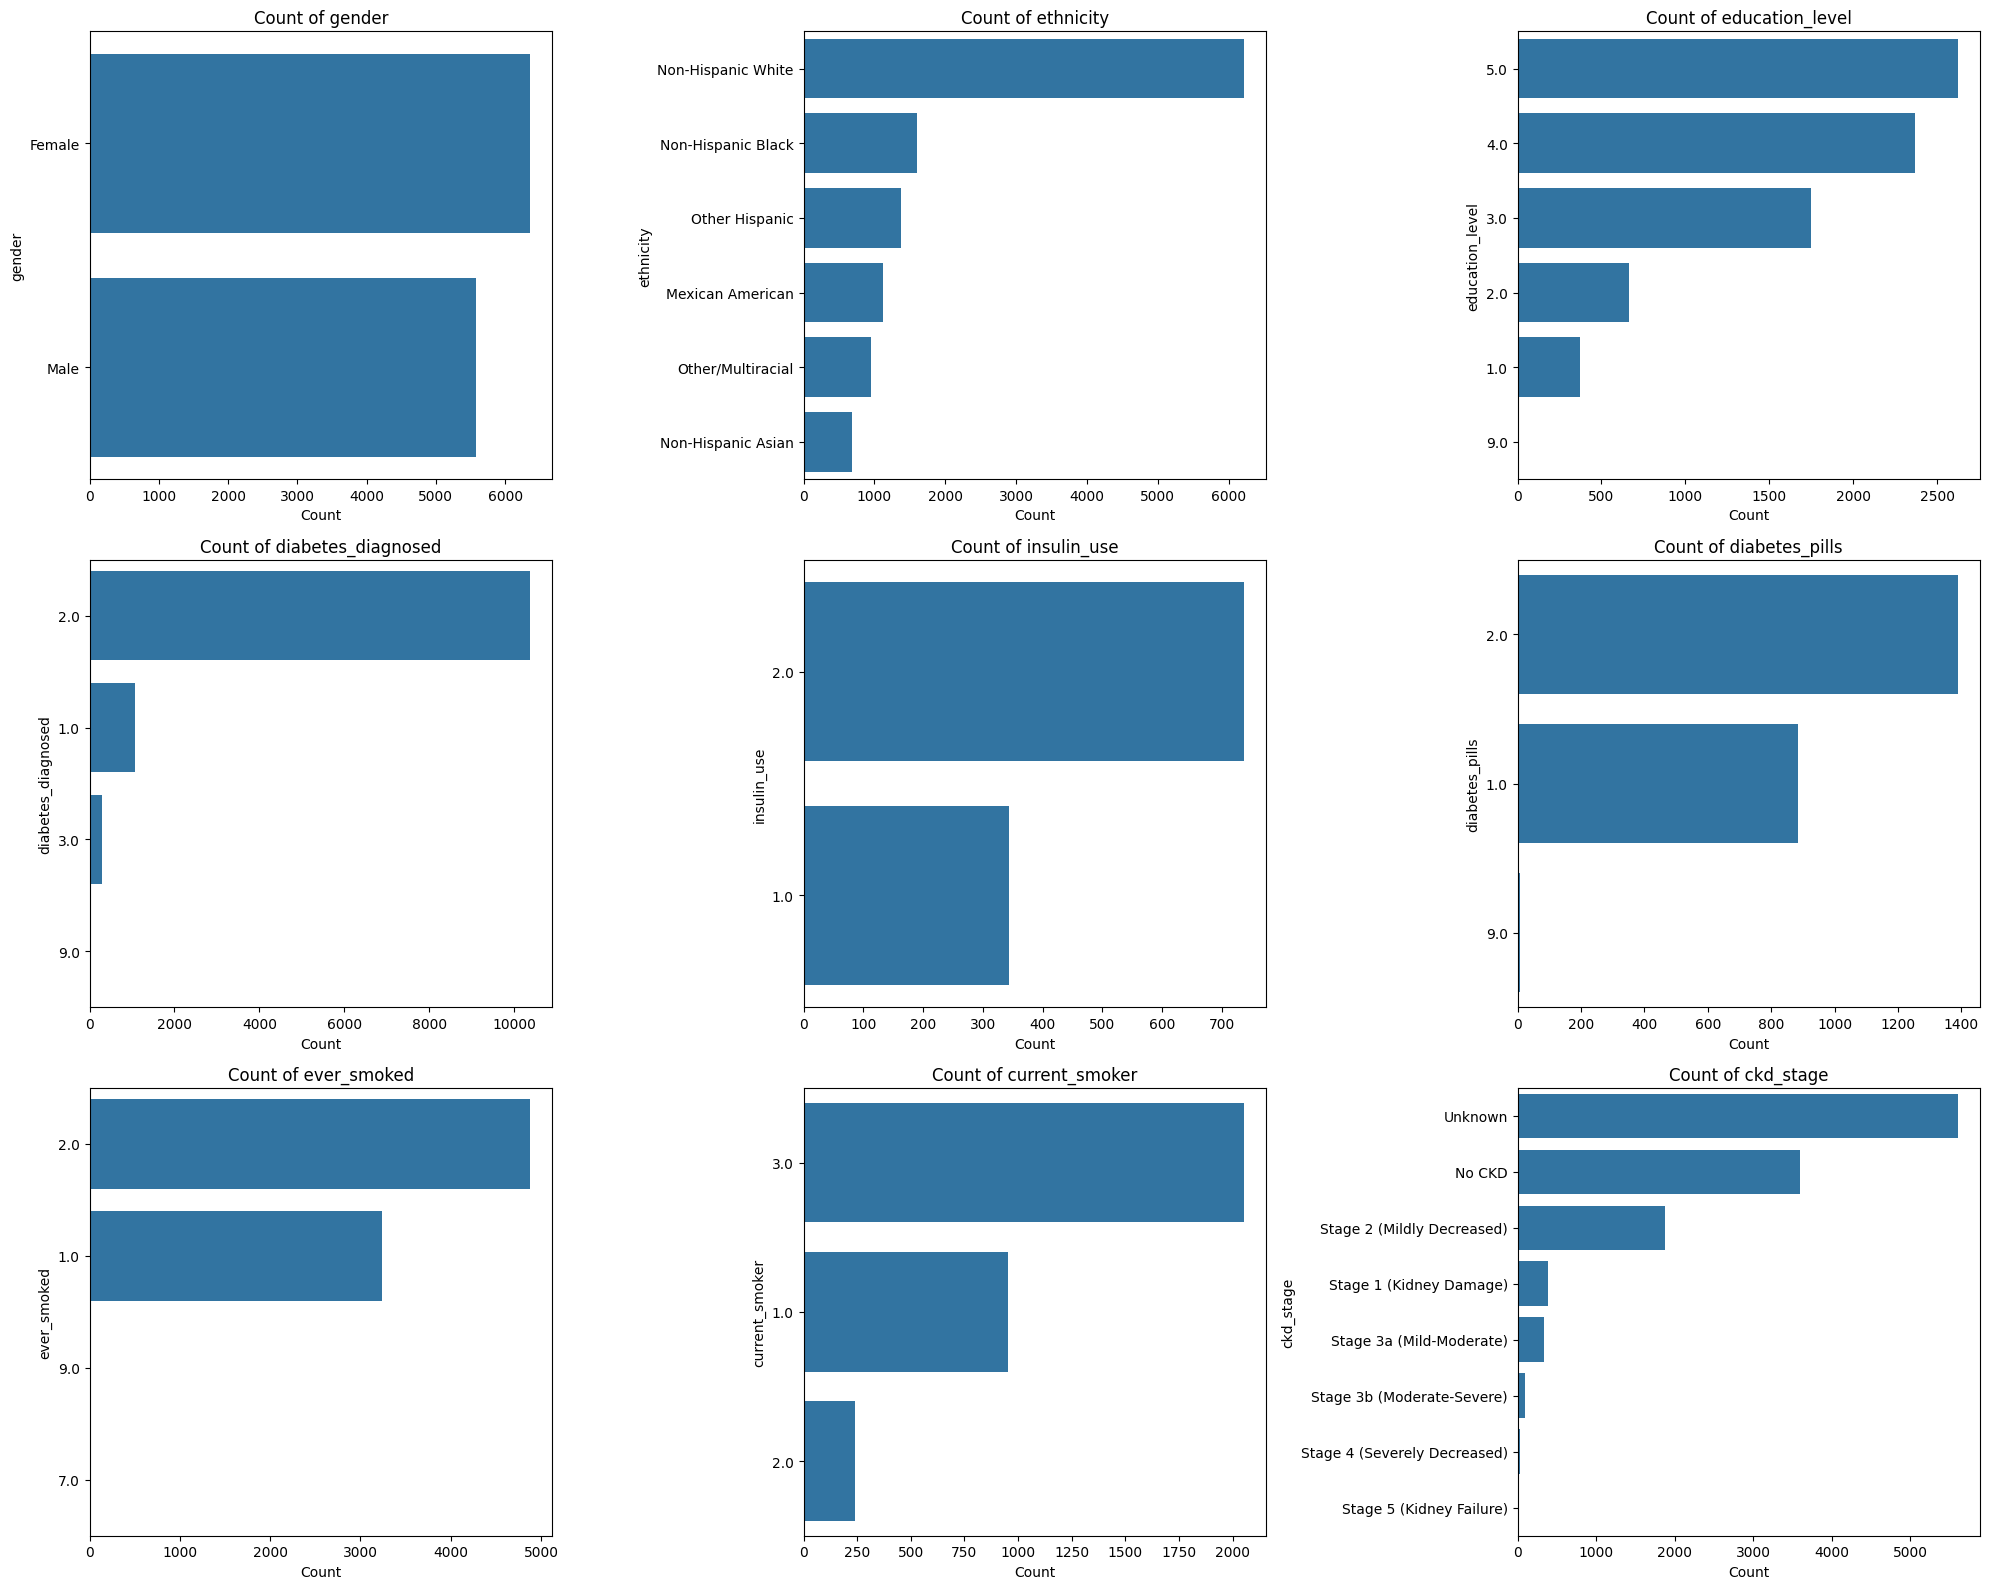

In [ ]:
# Select categorical columns
categorical_cols = [
    'gender','ethnicity','education_level','diabetes_diagnosed','insulin_use','diabetes_pills','ever_smoked','current_smoker','ckd_stage'
]


# Distribution of Categorical Features
plt.figure(figsize=(20, 16))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )

    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#### **Categorical Analysis**
* **Gender**: The dataset is relatively balanced between male and female participants, with females slightly more represented.

* **Ethnicity**: Non-Hispanic White participants represent the largest ethnic group, followed by Non-Hispanic Black and Hispanic populations.

* **Education Level**: Higher education categories (levels 4 and 5) are more dominant compared to lower education levels.

* **Diabetes Diagnosed**: Most participants are not diagnosed with diabetes, while only a smaller proportion report having diabetes.

* **Insulin Use**: Insulin usage is relatively low, indicating that only a small subset of participants require insulin treatment.

* **Diabetes Pills**: The majority of participants do not use diabetes medication pills.

* **Ever Smoked**: Most participants reported never smoking, although a considerable number have a history of smoking.

* **Current Smoker**: Current smokers represent a smaller portion of the dataset compared to non-smokers.

* **CKD Stage**: Most participants are categorized as “Unknown” or “No CKD,” while advanced CKD stages such as Stage 3b, Stage 4, and Stage 5 contain very few samples, indicating class imbalance in the target variable.


### **Bivariate Analysis**

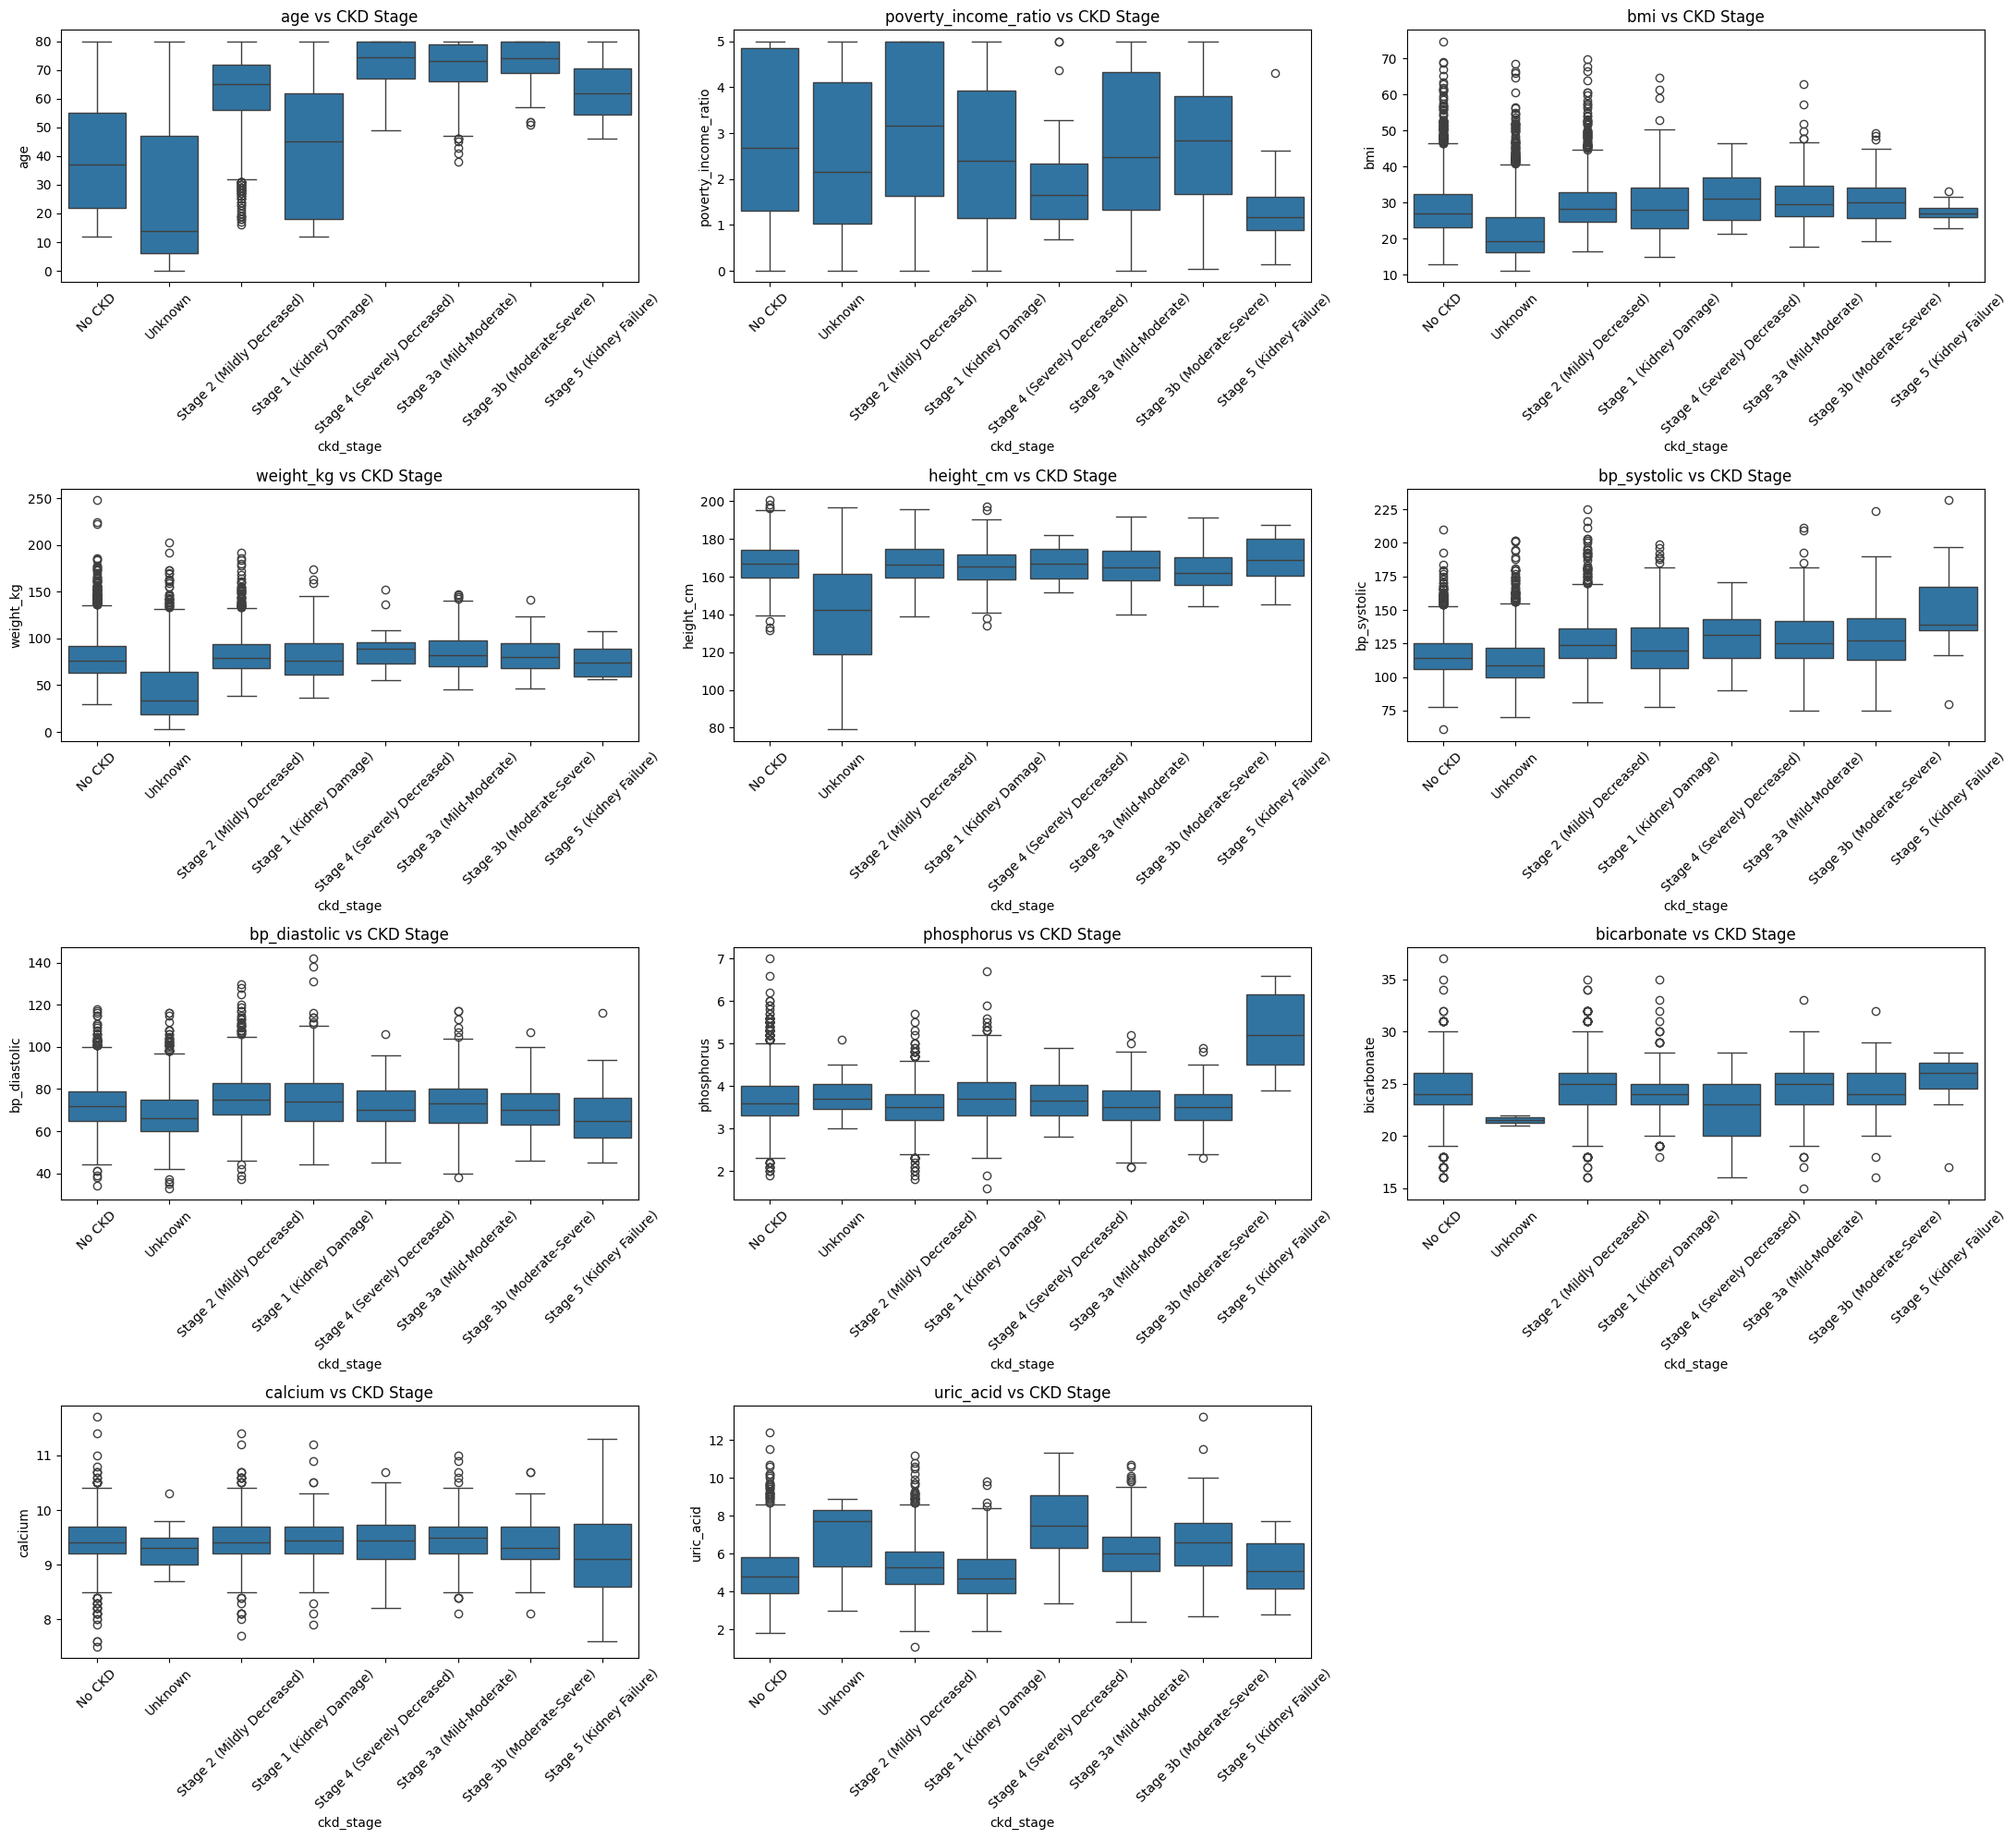

In [ ]:
# Numerical columns
numerical_cols = [
    'age',
    'poverty_income_ratio',
    'bmi',
    'weight_kg',
    'height_cm',
    'bp_systolic',
    'bp_diastolic',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid'
]

# ============================================================
# Boxplot Visualization
# ============================================================

plt.figure(figsize=(22, 20))

for i, col in enumerate(numerical_cols):

    plt.subplot(4, 3, i + 1)

    sns.boxplot(
        x='ckd_stage',
        y=col,
        data=df
    )

    plt.title(f'{col} vs CKD Stage')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### **Bivariate Analysis Summary**

* **Age is the strongest predictor of CKD severity**
  Older participants consistently show higher CKD stages, indicating a strong relationship between aging and CKD progression.

* **Phosphorus is highly indicative of advanced CKD**
  Phosphorus levels remain relatively stable across early CKD stages but increase sharply in Stage 5, reflecting severe kidney dysfunction.

* **Uric acid may help detect early CKD**
  Elevated uric acid levels are more noticeable in early CKD stages, suggesting potential usefulness for early-stage CKD detection.

* **BMI and weight show non-linear trends**
  Early CKD stages tend to have higher BMI and body weight, while advanced stages show lower values, possibly due to muscle wasting and declining health conditions.

* **Systolic blood pressure increases with CKD progression**
  Higher CKD stages generally exhibit elevated systolic blood pressure, supporting the relationship between hypertension and kidney disease.

* **Several features provide weak stage separation**
  Features such as poverty income ratio, diastolic blood pressure, bicarbonate, and calcium show substantial overlap across CKD stages, limiting their discriminative capability.

* **The “Unknown” CKD stage is highly heterogeneous**
  The “Unknown” category contains participants with very broad distributions across multiple features, suggesting that this group may represent individuals without complete kidney examinations rather than a true clinical CKD stage.

* **Most informative features for modeling**
  Age, phosphorus, uric acid, BMI, and systolic blood pressure appear to be the most useful predictors for CKD stage classification.



In [ ]:
pd.crosstab(
    df['diabetes_diagnosed'],
    df['ckd_stage']
)

ckd_stage,No CKD,Stage 1 (Kidney Damage),Stage 2 (Mildly Decreased),Stage 3a (Mild-Moderate),Stage 3b (Moderate-Severe),Stage 4 (Severely Decreased),Stage 5 (Kidney Failure),Unknown
diabetes_diagnosed,,,,,,,,
1.0,264,85,260,98,41,12,6,315
2.0,3228,283,1549,226,49,16,5,5015
3.0,99,14,66,17,7,0,0,81
9.0,1,0,0,0,0,0,0,3


### **Outlier Analysis**

In [ ]:
# Features to analyze
lab_outlier_cols = [
    'phosphorus',
    'uric_acid',
    'calcium','bmi', 'weight_kg', 'bp_systolic'
]

for col in lab_outlier_cols:

    # Remove missing values
    data = df[col].dropna()

    # Calculate Q1, Q3, and IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n========== {col.upper()} ==========")
    print(f"Q1              : {Q1:.2f}")
    print(f"Q3              : {Q3:.2f}")
    print(f"IQR             : {IQR:.2f}")
    print(f"Lower Bound     : {lower_bound:.2f}")
    print(f"Upper Bound     : {upper_bound:.2f}")
    print(f"Total Outliers  : {len(outliers)}")

plt.figure(figsize=(15, 5))

for i, col in enumerate(lab_outlier_cols):

    plt.subplot( 1, 6, i + 1)

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

#### **Outlier Analysis Summary**

Outlier detection was performed using the IQR (1.5×IQR) method on both physical measurement features (`bmi`, `weight_kg`, `bp_systolic`) and laboratory biomarkers (`phosphorus`, `uric_acid`, `calcium`). The detected extreme values were then clinically evaluated to determine whether they represent data errors or medically valid conditions.


### **Key Insights**

* The IQR method detected:

  * **189 outliers** in `bmi`
  * **137 outliers** in `weight_kg`
  * **143 outliers** in `bp_systolic`

* Extremely low values in `bmi` and `weight_kg` are likely associated with pediatric participants rather than invalid records.

* The upper IQR bound for `bp_systolic` (166 mmHg) already falls within severe hypertension ranges commonly observed in CKD patients, indicating that many flagged outliers are clinically meaningful.

* `calcium` has a very small IQR (0.50), causing the IQR bounds to almost perfectly overlap with normal clinical laboratory ranges. This shows that the IQR method is not suitable for tightly regulated biomarkers.

* A similar issue occurs with `phosphorus`, where elevated phosphorus levels in advanced CKD patients are clinically valid despite being flagged as outliers by the IQR method.

* `uric_acid` shows a more flexible distribution, but extremely high values still represent medically valid hyperuricemia conditions rather than noise.

* Overall, many detected outliers in healthcare datasets represent important clinical abnormalities instead of data entry errors.


### **Recommended Decisions**

* Outliers in `bmi` and `weight_kg` should first be validated together with the `age` feature before deciding whether treatment is necessary.

* High outlier values in `bp_systolic` and `phosphorus` should be fully retained because they contain important clinical information relevant to CKD prediction.

* For `calcium`, explicit clinical reference ranges should be used instead of relying solely on the IQR method. Only extremely abnormal values should be considered problematic.

* For `uric_acid`, only extremely low values should be considered for winsorization or correction.

* Winsorization or clipping is preferred over removing rows in order to preserve valuable clinical cases and maintain dataset size.

* During preprocessing, `RobustScaler` is recommended because it is more resistant to the influence of extreme values compared to `StandardScaler`.

* In general, statistical outlier detection methods should always be validated against clinical laboratory reference ranges before applying preprocessing decisions in healthcare datasets.



### **Correlation Heatmap Analysis**

Numerical Columns:
Index(['age', 'education_level', 'poverty_income_ratio', 'bmi', 'weight_kg',
       'height_cm', 'bp_systolic', 'bp_diastolic', 'phosphorus', 'bicarbonate',
       'calcium', 'uric_acid', 'diabetes_diagnosed', 'insulin_use',
       'diabetes_pills', 'ever_smoked', 'current_smoker'],
      dtype='object')


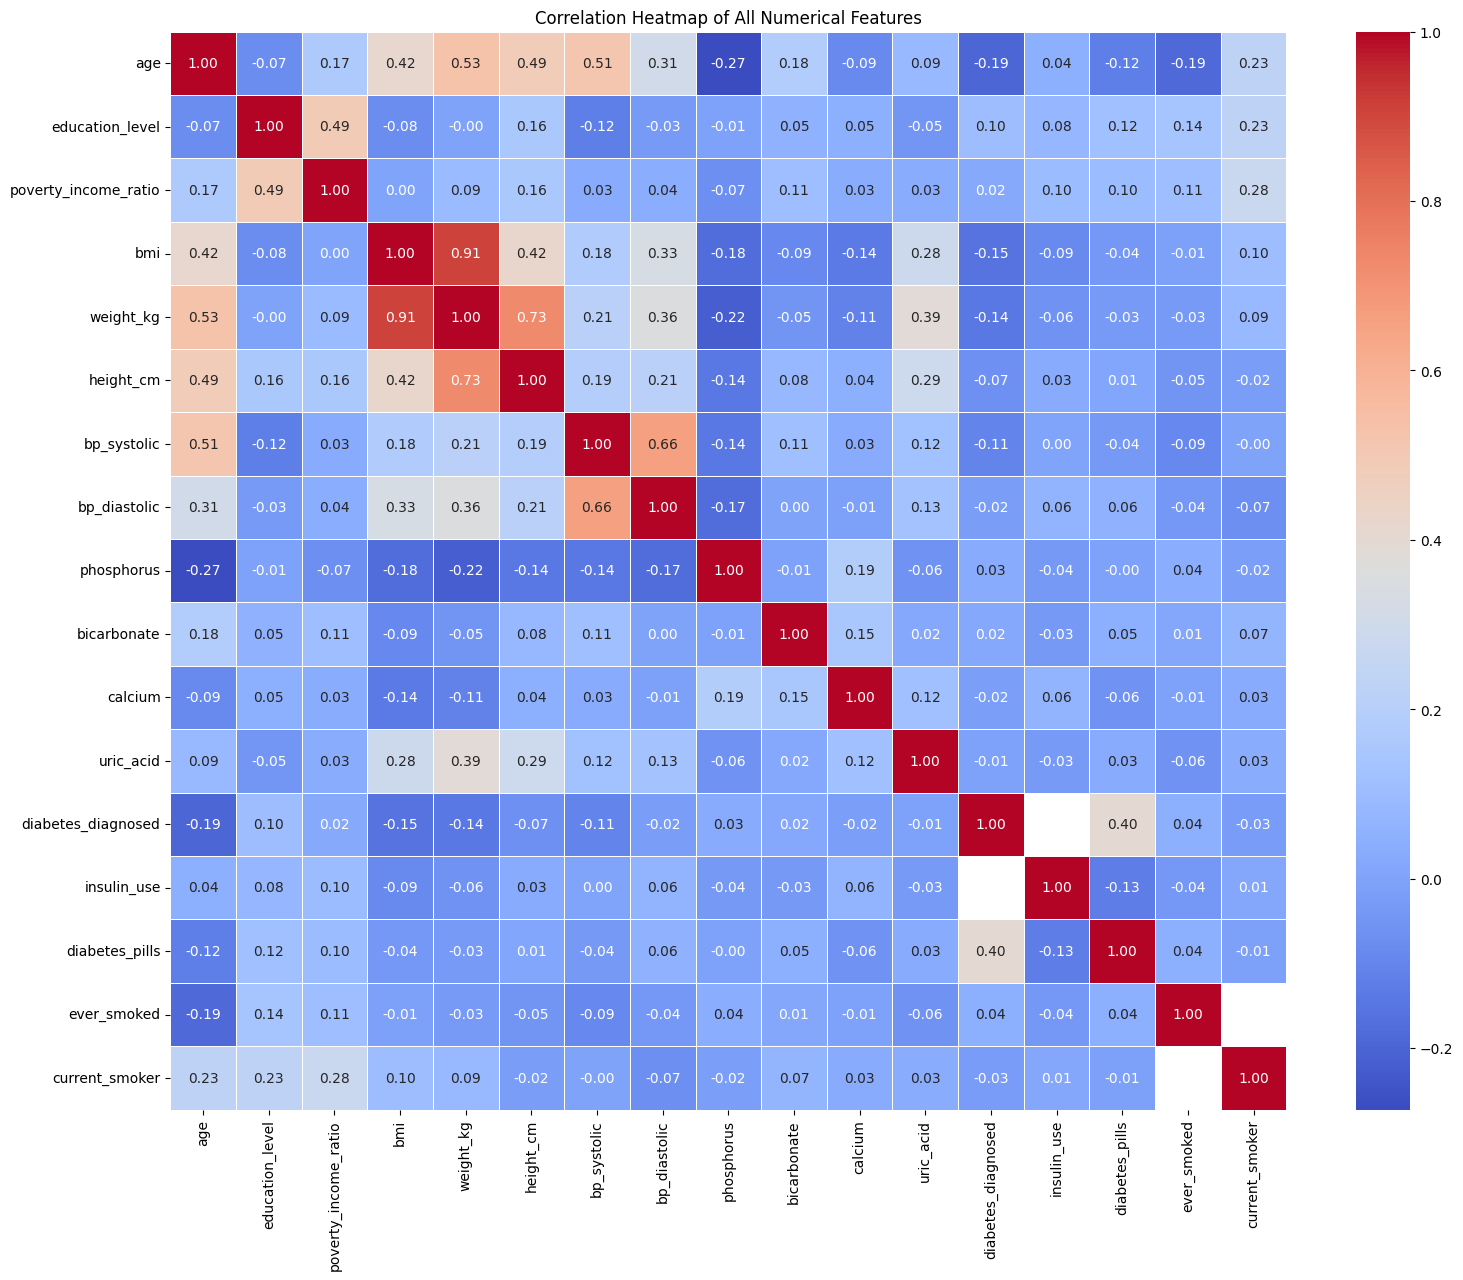

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_cols)

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of All Numerical Features')
plt.show()

#### **Heatmap Correlation Analysis Summary**


### **Short Explanation**

Pearson correlation analysis was performed on all numerical features to identify multicollinearity and understand linear relationships between variables before feature selection and machine learning modeling.

### **Key Insights**

* The strongest multicollinearity was observed between `bmi` and `weight_kg` with a correlation coefficient of **r = 0.91**, indicating that both variables contain highly redundant information.

* Strong positive correlations were also found between:

  * `weight_kg` and `height_cm` (**r = 0.73**)
  * `bp_systolic` and `bp_diastolic` (**r = 0.66**)

* `age` acts as a strong confounding variable because it shows moderate correlations with several health-related features simultaneously, including:

  * `bmi` (**r = 0.42**)
  * `weight_kg` (**r = 0.53**)
  * `height_cm` (**r = 0.49**)
  * `bp_systolic` (**r = 0.51**)

* Laboratory biomarkers (`phosphorus`, `bicarbonate`, `calcium`, and `uric_acid`) show very weak correlations with one another (**all r < 0.20**), suggesting that each biomarker contributes unique and complementary clinical information.

* The moderate correlation between `education_level` and `poverty_income_ratio` suggests a possible socioeconomic relationship within the dataset.

### **Recommended Decisions**

* `weight_kg` may be dropped and represented indirectly through `bmi` to reduce multicollinearity.

* `bp_systolic` and `bp_diastolic` can be combined into a clinically meaningful feature such as Mean Arterial Pressure (MAP):

* All laboratory biomarkers should be retained because they provide independent predictive signals.

* Socioeconomic variables such as `education_level` and `poverty_income_ratio` may later be combined into a single socioeconomic status component using dimensionality reduction techniques such as PCA if model simplification is needed.

* Multicollinearity handling should be prioritized before applying linear-based machine learning models.


# **Data Preprocessing**

### **Data Cleaning**

#### **Data Cleaning**

The data cleaning phase focuses on removing invalid survey codes, handling ambiguous target labels, and preparing the dataset for reliable preprocessing and modeling.

---

### **Key Insights**

* Survey response codes such as `7` and `9` represent invalid or unknown responses rather than meaningful categories.

* The `Unknown` category in `ckd_stage` does not represent a clinically validated CKD stage and may introduce label noise during modeling.

* Keeping invalid survey codes or ambiguous target labels may reduce model reliability and distort predictions.

---

### **Decisions**

* Replace invalid survey codes (`7` and `9`) with `NaN` values before preprocessing.

* Remove the `Unknown` CKD stage from the modeling dataset while optionally preserving it for exploratory analysis.

---



In [ ]:
# -- Preprocessing (all steps via src.preprocessing) --
# Multiclass-specific: filters Unknown/No CKD rows, imputes lab/BP grouped
# by ckd_stage, groups stages into Early/Moderate/Advanced, label-encodes target.
df_clean, label_encoder = preprocess_pipeline(df, task='multiclass')

CLASS_NAMES = list(label_encoder.classes_)   # ['Advanced', 'Early', 'Moderate']
print(f'Classes (encoded 0,1,2): {CLASS_NAMES}')
print(f'Shape after preprocessing : {df_clean.shape}')
print(f'Missing values            : {df_clean.isnull().sum().sum()}')
print(f'Target distribution:\n{df_clean["ckd_stage_grouped"].value_counts()}')

Classes (encoded 0,1,2): ['Advanced', 'Early', 'Moderate']
Shape after preprocessing : (2734, 22)
Missing values            : 104
Target distribution:
ckd_stage_grouped
2    1875
0     477
1     382
Name: count, dtype: int64


### **Missing Value Imputation**

#### **Missing Value Imputation**

Missing value handling was designed based on the clinical meaning and data collection mechanism of each feature instead of applying a single global imputation strategy.

---

### **Key Insights**

* Missing values in `insulin_use` and `diabetes_pills` are structurally missing because these questions were only asked to diabetic participants.

* Smoking-related features contain complementary information that can be merged into a more informative smoking status feature.

* Laboratory biomarkers and blood pressure measurements show different distributions across CKD stages, making stage-aware imputation more appropriate than global imputation.

* Physical measurements such as BMI, weight, and height vary substantially across age and gender groups.

---

### **Recommended Decisions**

* Recode missing values in `insulin_use` and `diabetes_pills` as non-applicable instead of performing conventional imputation.

* Create a new `smoking_status` feature by combining smoking-related variables

* Impute laboratory values and blood pressure using median values grouped by CKD stage.

* Impute BMI, weight, and height using median values grouped by age and gender.

* Impute `education_level` using the mode grouped by age and ethnicity.

---

In [ ]:
# Handled by preprocess_pipeline() above.

### **Feature Engineering**

#### **Feature Engineering**

### **Short Explanation**

Feature engineering was performed to create clinically meaningful variables, reduce redundancy, and capture non-linear patterns identified during EDA.

---

### **Key Insights**

* Blood pressure variables are strongly correlated and can be represented more effectively using Mean Arterial Pressure (MAP).


* Age distributions indicate distinct pediatric, adult, and elderly populations.

* BMI categories may provide more interpretable clinical information than raw BMI values.

* `weight_kg` is highly redundant with `bmi`.

---

### **Recommended Decisions**

* Create the MAP feature using:


* MAP = \frac{bp_{systolic} + 2(bp_{diastolic})}{3}

* Create categorical `age_group` and `bmi_category` features.

* Drop `weight_kg` after feature engineering due to high multicollinearity with BMI.

---

In [ ]:
# Handled by preprocess_pipeline() above.

### **Encoding**

#### **Encoding**


Categorical variables were encoded based on their intrinsic characteristics, including ordinal relationships, binary representation, and nominal categories.

---

### **Key Insights**

* Several variables naturally contain ordinal relationships and should preserve their ranking information.

* Binary variables can be simplified into 0/1 representation for easier modeling.

* Ethnicity does not contain any natural ordering and requires one-hot encoding.

---

### **Recommended Decisions**

* Apply ordinal encoding for `education_level`, `age_group`, `bmi_category`, and `smoking_status`.

* Apply binary encoding for gender, diabetes-related variables, and laboratory testing indicators.

* Apply one-hot encoding for `ethnicity` using `drop_first=True`.

---

In [ ]:
# Handled by preprocess_pipeline() above.

### **Outlier Treatment**

#### **Outlier Treatment**

Outlier treatment was designed using clinically informed thresholds rather than relying solely on statistical methods.

---

### **Key Insights**

* Many extreme values in healthcare data represent valid clinical conditions rather than measurement errors.

* Elevated phosphorus and systolic blood pressure values are clinically meaningful indicators of advanced CKD.

* IQR-based outlier detection is not always appropriate for tightly regulated biomarkers such as calcium.

---

### **Recommended Decisions**

* Apply winsorization for BMI-related features using clinically realistic limits.

* Retain high values in `phosphorus` and `bp_systolic`.

* Use explicit clinical thresholds for calcium outlier handling.

---

In [ ]:
# Handled by preprocess_pipeline() above.

### **Split Data**

In [ ]:
TARGET = 'ckd_stage_grouped'

X_train, X_test, y_train, y_test = split_data(df_clean, TARGET)
X_train, scaler                  = fit_scaler(X_train)
X_test                           = apply_scaler(X_test, scaler)

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Class distribution (train):\n{y_train.value_counts()}')

X_train : (2187, 21)  |  X_test : (547, 21)
Class distribution (train):
ckd_stage_grouped
2    1500
0     381
1     306
Name: count, dtype: int64


### **Scaling & Normalization**

#### **Scaling & Normalization**

Feature scaling was performed to improve model stability while preserving clinically meaningful outliers.

---

### **Key Insights**

* Most numerical variables show right-skewed distributions.

* Several clinically important outliers are intentionally preserved.

* Standard scaling methods may be heavily influenced by extreme values.

---

### **Recommended Decisions**

* Use `RobustScaler` for continuous numerical features because it is resistant to skewed distributions and outliers.

---

In [ ]:
# Scaling handled in split cell above.

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (2187, 21)
X_test shape : (547, 21)


# **Modelling**

### **Define Models**


In [ ]:
# -- Stratified 5-Fold CV with per-fold sample weights --
cv_results = stratified_cv_multiclass(build_catboost(), X_train, y_train)

Fold 1 | Acc: 0.664 | Macro F1: 0.622 | Adv: 0.671 | Early: 0.774 | Mod: 0.640 | Kappa: 0.413
Fold 2 | Acc: 0.626 | Macro F1: 0.580 | Adv: 0.649 | Early: 0.689 | Mod: 0.607 | Kappa: 0.351
Fold 3 | Acc: 0.625 | Macro F1: 0.566 | Adv: 0.632 | Early: 0.590 | Mod: 0.630 | Kappa: 0.325
Fold 4 | Acc: 0.664 | Macro F1: 0.623 | Adv: 0.763 | Early: 0.738 | Mod: 0.623 | Kappa: 0.425
Fold 5 | Acc: 0.659 | Macro F1: 0.600 | Adv: 0.645 | Early: 0.639 | Mod: 0.667 | Kappa: 0.385

────────────────────────────────────────────────────────────
Average:
  accuracy              : 0.6475 ± 0.0183
  macro_f1              : 0.5984 ± 0.0227
  advanced_recall       : 0.6720 ± 0.0473
  early_recall          : 0.6860 ± 0.0661
  moderate_recall       : 0.6333 ± 0.0199
  kappa                 : 0.3799 ± 0.0374


In [ ]:
# -- Train Final Model 2 --
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from full training set
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_list = [float(w) for w in weights]

# Build CatBoost with class weights, then fit
best_catboost = build_catboost(class_weights_list=class_weights_list)
best_catboost.fit(X_train, y_train)

# Evaluate on hold-out test set
metrics = eval_multiclass(best_catboost, X_test, y_test, CLASS_NAMES)
for k, v in metrics.items():
    if k != 'report':
        print(f'{k}: {v:.4f}')

accuracy: 0.6106
macro_f1: 0.5710
kappa: 0.3413
roc_auc_ovr: 0.7848


### **Feature Importance**


In [ ]:
# See cv_results from stratified_cv_multiclass above.

# See cv_results from stratified_cv_multiclass above.

In [ ]:
# See cv_results from stratified_cv_multiclass above.

In [ ]:
# See cv_results from stratified_cv_multiclass above.

### **Evaluation**


In [ ]:
# best_catboost is set after training below.

In [ ]:
# Run after best_catboost is trained (see below).
# sensitivity_specificity(y_test, best_catboost.predict(X_test).ravel(), CLASS_NAMES)


### **DCA**



### **CALIBRATION ANALYSIS**


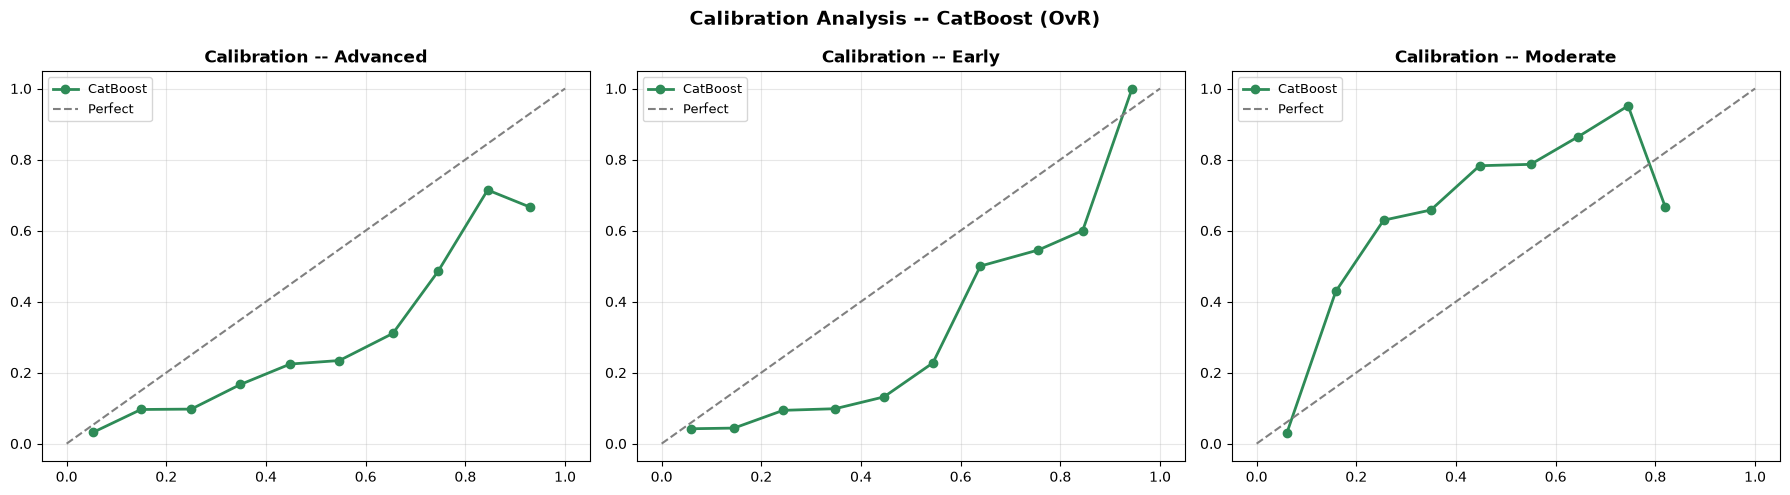


Brier Score per class:
  Advanced: 0.1498
  Early: 0.1000
  Moderate: 0.2499


In [ ]:
# -- Calibration Curve Analysis (run after training best_catboost) --
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_proba_cat = best_catboost.predict_proba(X_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, class_name in enumerate(CLASS_NAMES):
    y_binary = (y_test == idx).astype(int)
    frac_pos, mean_pred = calibration_curve(y_binary, y_proba_cat[:, idx],
                                            n_bins=10, strategy='uniform')
    axes[idx].plot(mean_pred, frac_pos, marker='o', lw=2, label='CatBoost', color='seagreen')
    axes[idx].plot([0,1],[0,1], linestyle='--', color='gray', label='Perfect')
    axes[idx].set_title(f'Calibration -- {class_name}', fontweight='bold')
    axes[idx].legend(fontsize=9); axes[idx].grid(alpha=0.3)
plt.suptitle('Calibration Analysis -- CatBoost (OvR)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nBrier Score per class:')
for idx, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {brier_score_loss((y_test==idx).astype(int), y_proba_cat[:,idx]):.4f}')


### **Confusion Matrix**


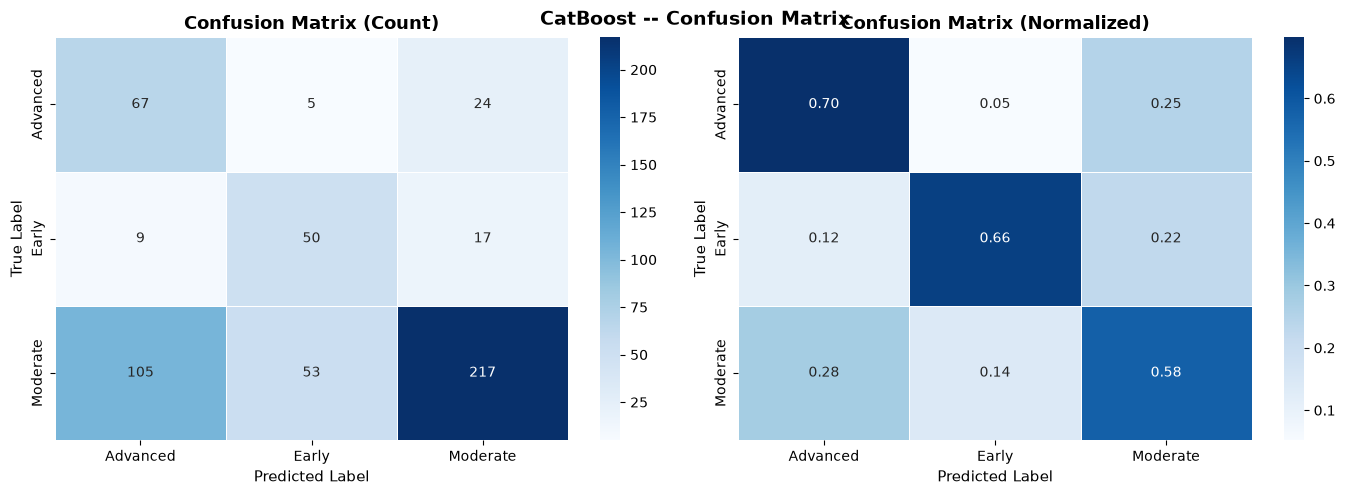

In [ ]:
# -- Confusion Matrix --
y_pred_final = best_catboost.predict(X_test).ravel()
fig = plot_confusion_matrix(y_test, y_pred_final, CLASS_NAMES)
plt.suptitle('CatBoost -- Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


### **ROC-AUC Analysis**



ROC-AUC per class:
  Advanced    : 0.7776
  Early       : 0.8309
  Moderate    : 0.7458
  Macro Avg   : 0.7866


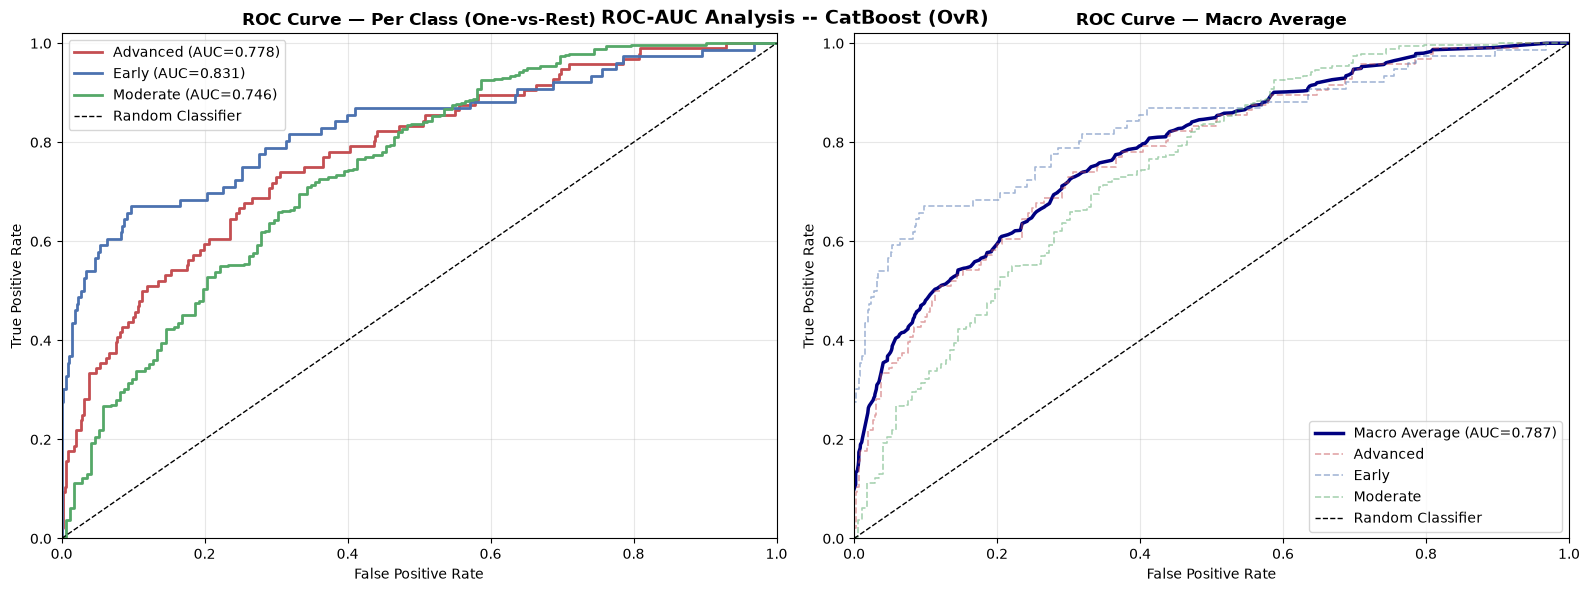

In [ ]:
# -- ROC-AUC (One-vs-Rest) --
fig = plot_roc_auc_ovr(best_catboost, X_test, y_test, CLASS_NAMES)
plt.suptitle('ROC-AUC Analysis -- CatBoost (OvR)', fontsize=14, fontweight='bold')
plt.show()


### **Hyperparameter Tuning**


In [ ]:
# -- Hyperparameter Tuning (Optuna, 100 trials) --
# Manual 5-fold CV with per-fold sample_weight to optimise macro recall.
# Skip and use CATBOOST_DEFAULT_PARAMS if already tuned.
best_params = tune_catboost(X_train, y_train)

### **Simpan Model**

In [ ]:
# -- Train Final Model --
# Default: uses CATBOOST_DEFAULT_PARAMS; pass params=best_params after tuning.
best_catboost = train_model2(X_train, y_train)

metrics = eval_multiclass(best_catboost, X_test, y_test, CLASS_NAMES)
for k, v in metrics.items():
    if k != 'report':
        print(f'{k}: {v:.4f}')

sensitivity_specificity(y_test, best_catboost.predict(X_test).ravel(), CLASS_NAMES)

# -- Save --
save_model2(best_catboost)

accuracy: 0.6106
macro_f1: 0.5710
kappa: 0.3413
roc_auc_ovr: 0.7848

Class           Sensitivity  Specificity
────────────────────────────────────────
Advanced              0.698        0.747
Early                 0.658        0.877
Moderate              0.579        0.762
Model saved → d:\Coding Vscode\CKD-Staging\ckd-severity-staging\notebooks\..\models\model2_catboost.pkl


### **SHAP Analysis**

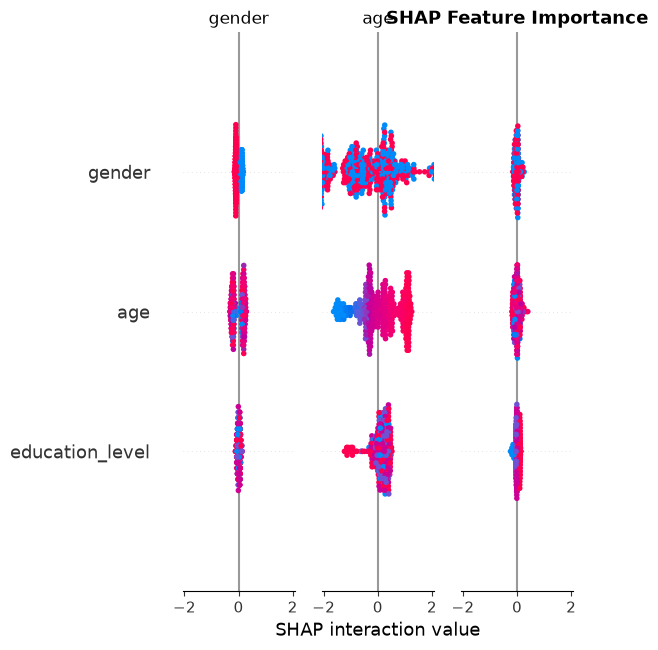

In [ ]:
# -- SHAP Analysis --
explainer, shap_values = get_shap_values(best_catboost, X_test)
plot_shap_bar(shap_values, X_test)

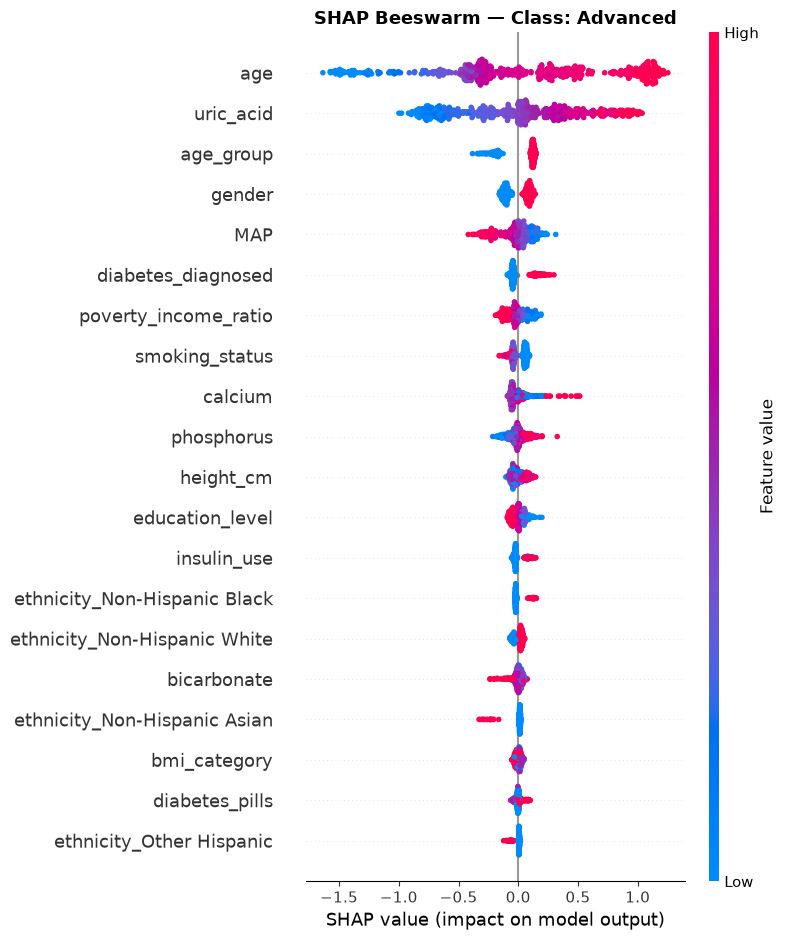

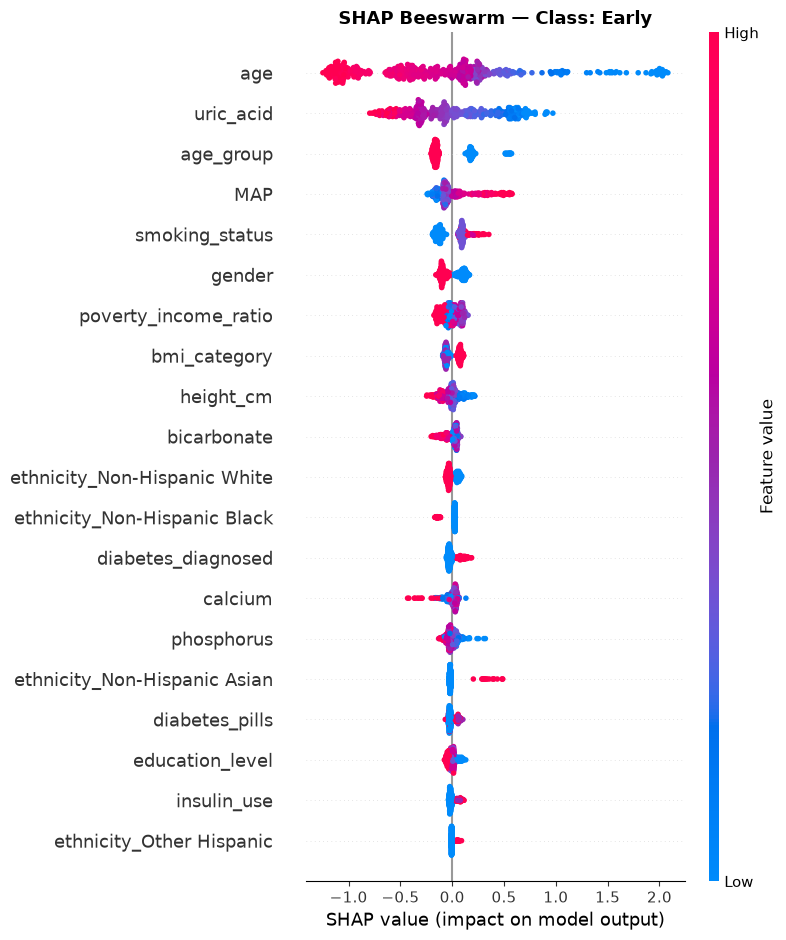

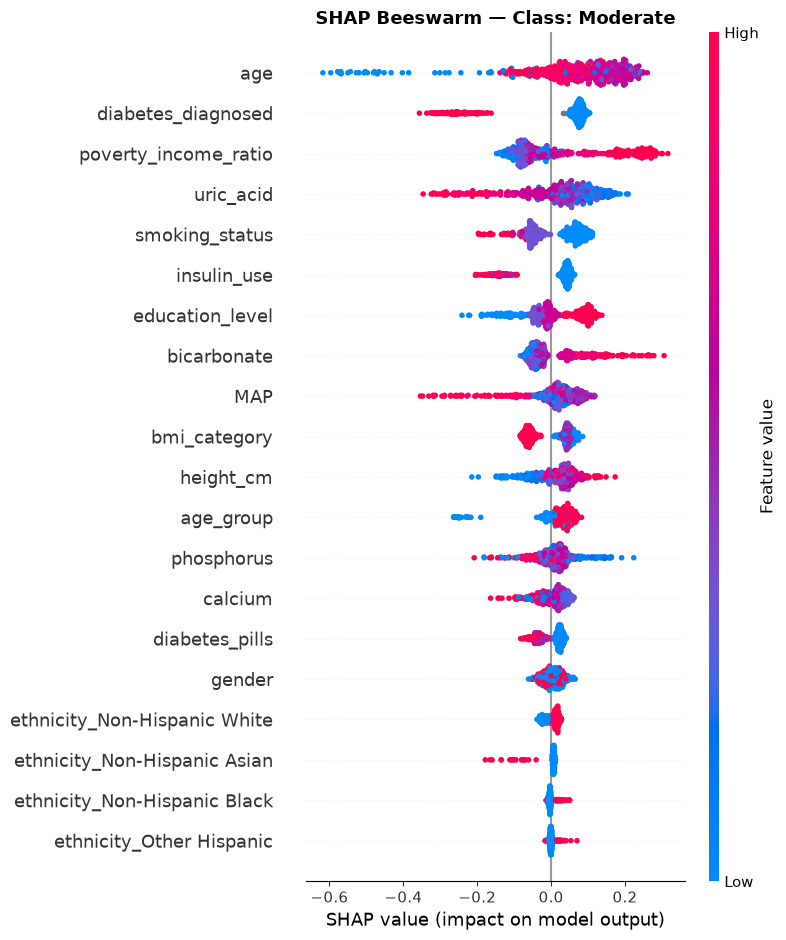

In [ ]:
# Per-class beeswarm plots
for idx, name in enumerate(CLASS_NAMES):
    plot_shap_beeswarm(shap_values, X_test, class_idx=idx, class_name=name)

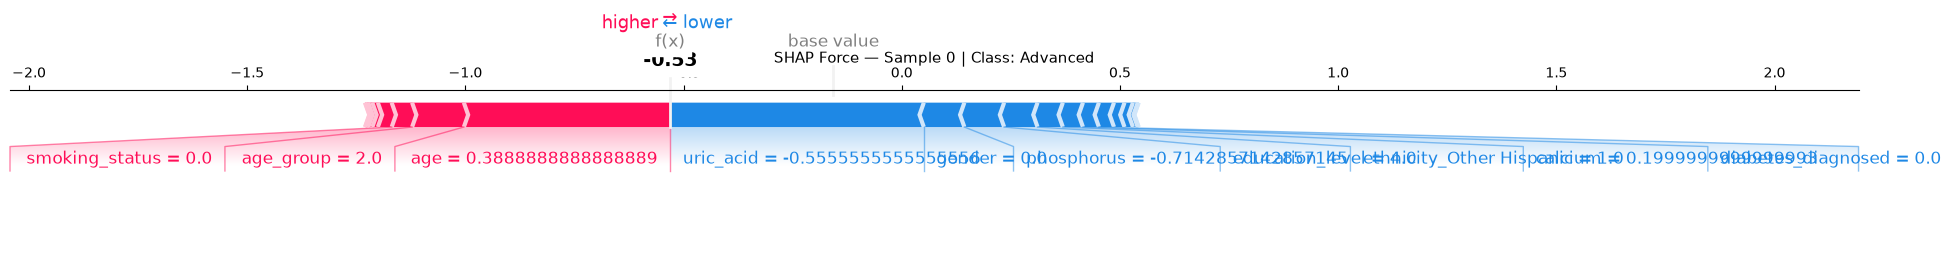

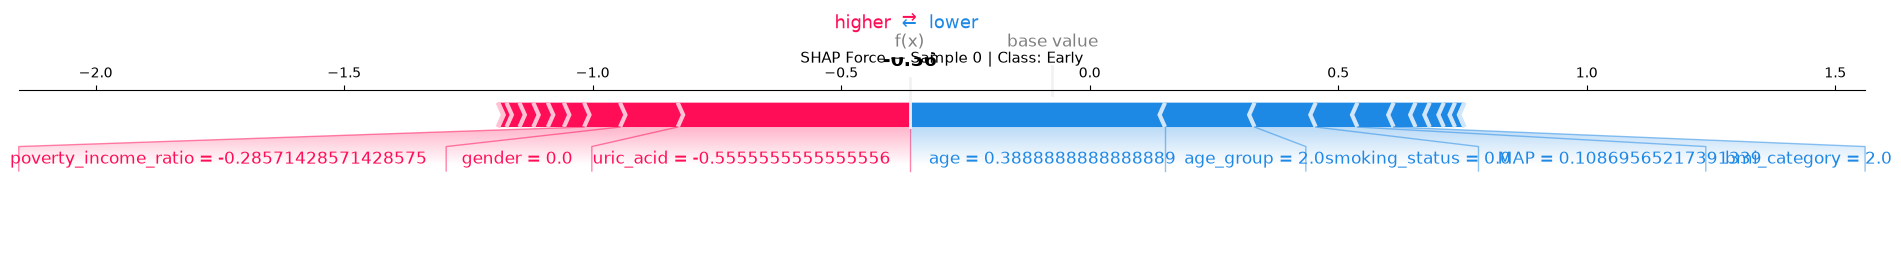

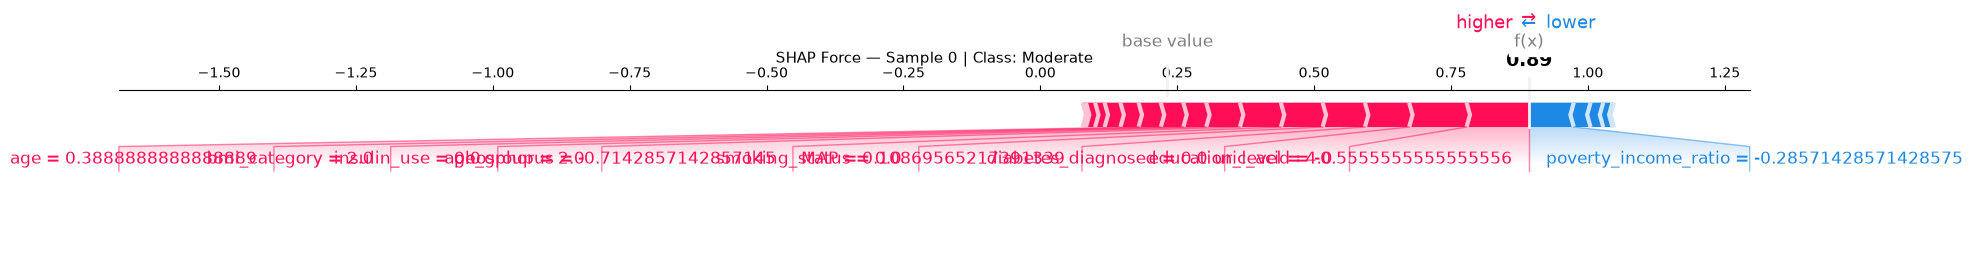

In [ ]:
# Force plot for sample 0, per class
for idx, name in enumerate(CLASS_NAMES):
    plot_shap_force(explainer, shap_values, X_test, idx=0, class_idx=idx, class_name=name)

In [ ]:
# Per-class beeswarm handled in the cell above via plot_shap_beeswarm.